# Credit Basis, Cross Market RV, and Optionality

One issuer view across cash, CDS, funding, cross-currency basis, a TY hedge, and a TY call overlay.


In [13]:
from decimal import Decimal

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from fuggers_py.core import Currency, Date, Frequency, Price
from fuggers_py.core.daycounts import DayCountConvention
from fuggers_py.credit import CdsQuote
from fuggers_py.market.state import AnalyticsCurves
# Public curve imports now start at fuggers_py.curves.
from fuggers_py.curves import YieldCurve
# This notebook still needs a later full rewrite for the current credit and funding curve helpers.
from fuggers_py.credit import adjusted_cds_breakdown, bond_cds_basis_breakdown
from fuggers_py.funding import specialness_spread
from fuggers_py.rates import option_rv_signal
from fuggers_py.bonds import BondRiskCalculator
from fuggers_py.bonds import decompose_asw_basis_cds_links, usd_sofr_adjusted_rv_from_links
from fuggers_py.bonds import BenchmarkSpec, GSpreadCalculator, GovernmentCurve, ISpreadCalculator, ParParAssetSwap, z_spread
from fuggers_py.bonds import BondPricer
from fuggers_py.credit import CdsPricer
from fuggers_py.rates import AssetSwapPricer
from fuggers_py.rates import cheapest_to_deliver, oabpv
from fuggers_py.rates import Black76Pricer
from fuggers_py.credit import CreditDefaultSwap, ProtectionSide
from fuggers_py.rates import AssetSwap, FloatingLegSpec, PayReceive, ScheduleDefinition
from fuggers_py.rates import DeliverableBasket, DeliverableBond, GovernmentBondFuture
from fuggers_py.rates import FuturesOption
from fuggers_py.reference import BondFutureReferenceData, BondReferenceData, BondType, CdsReferenceData, DeliverableBondReference, IssuerType, Tenor


def dec(value: object) -> Decimal:
    return value if isinstance(value, Decimal) else Decimal(str(value))


def pct(value: Decimal, digits: int = 2) -> str:
    return f"{100.0 * float(value):.{digits}f}%"


def bp(value: Decimal, digits: int = 1) -> str:
    return f"{10000.0 * float(value):,.{digits}f}"


## 1. Setup

Fix the small trade universe and shared assumptions first.


In [14]:
trade_date = Date.parse('2026-01-15')

cash_bond_id = 'ACME_5Y_2031'
cds_ids = ['ACME_CDS_1Y', 'ACME_CDS_3Y', 'ACME_CDS_5Y', 'ACME_CDS_7Y', 'ACME_CDS_10Y']
basis_ids = ['EURUSD_BASIS_1Y', 'EURUSD_BASIS_2Y', 'EURUSD_BASIS_3Y', 'EURUSD_BASIS_5Y', 'EURUSD_BASIS_7Y']
rates_future_id = 'TYM6'
deliverable_ids = ['UST_7Y_2033', 'UST_10Y_2036']
option_ids = ['TYM6C110', 'TYM6C112', 'TYM6C114']
rates_option_id = 'TYM6C112'

trade_notional = dec('10000000')
specific_repo_rate = dec('0.0394')
option_realized_volatility = dec('0.1630')
cds_delivery_option_adjustment = dec('0.0005')
cds_other_adjustment = dec('0.0003')


In [15]:
cash_quote = pd.read_csv('synthetic_data/bonds/cash_bond_market_levels.csv').set_index(['instrument_id', 'quote_field'])['value']
future_quote = pd.read_csv('synthetic_data/rates/rates_future_chain.csv').set_index(['instrument_id', 'quote_field'])['value']
option_quote = pd.read_csv('synthetic_data/rates/rates_option_smile.csv').set_index(['instrument_id', 'quote_field'])['value']

benchmark_strip = sorted(
    pd.read_csv('synthetic_data/curves/nominal_government_curve.csv').to_dict('records'),
    key=lambda row: Tenor.parse(row['tenor']).to_years_approx(),
)
discount_strip = sorted(
    pd.read_csv('synthetic_data/curves/ois_discount_curve.csv').to_dict('records'),
    key=lambda row: Tenor.parse(row['tenor']).to_years_approx(),
)
repo_strip = sorted(
    pd.read_csv('synthetic_data/curves/repo_funding_curve.csv').to_dict('records'),
    key=lambda row: Tenor.parse(row['tenor']).to_years_approx(),
)
cds_strip = pd.read_csv('synthetic_data/credit/cds_par_spreads.csv').set_index('instrument_id').loc[cds_ids].reset_index().to_dict('records')
basis_strip = pd.read_csv('synthetic_data/fx/cross_currency_basis.csv').set_index('instrument_id').loc[basis_ids].reset_index().to_dict('records')
option_smile = pd.read_csv('synthetic_data/rates/rates_option_smile.csv').set_index('instrument_id').loc[option_ids].reset_index().to_dict('records')

bond_reference = pd.read_csv('synthetic_data/bonds/instruments.csv', dtype=str, keep_default_na=False).set_index('instrument_id').loc[[cash_bond_id, *deliverable_ids]]
cds_reference_slice = pd.read_csv('synthetic_data/credit/cds_families.csv', dtype=str, keep_default_na=False).set_index('instrument_id').loc[cds_ids]
future_entry = pd.read_csv('synthetic_data/rates/rates_futures.csv', dtype=str, keep_default_na=False).set_index('instrument_id').loc[rates_future_id]
option_reference_slice = pd.read_csv('synthetic_data/rates/rates_options.csv', dtype=str, keep_default_na=False).set_index('instrument_id').loc[option_ids]


In [16]:
ACT_365 = DayCountConvention.ACT_365_FIXED.to_day_count()

cash_entry = bond_reference.loc[cash_bond_id]
cash_bond = BondReferenceData(
    instrument_id=cash_bond_id,
    bond_type=BondType.FIXED_RATE,
    issuer_type=IssuerType.CORPORATE,
    issue_date=Date.parse(cash_entry['issue_date']),
    maturity_date=Date.parse(cash_entry['maturity_date']),
    currency=Currency.from_code(cash_entry['currency']),
    notional=dec(cash_entry['notional']),
    coupon_rate=dec(cash_entry['coupon_rate']),
    frequency=Frequency[cash_entry['frequency']],
    issuer_name=cash_entry['issuer'],
    sector=cash_entry['sector'],
    rating=cash_entry['rating'],
).to_instrument()
cash_rules = cash_bond.rules()
cash_settlement = cash_rules.settlement_rules.settlement_date(trade_date, cash_rules.calendar.to_calendar())

hedge_future = GovernmentBondFuture.from_reference(BondFutureReferenceData(
    instrument_id=rates_future_id,
    currency=Currency.from_code(future_entry['currency']),
    delivery_month=future_entry['delivery_month'],
    first_delivery_date=Date.parse(future_entry['first_delivery_date']),
    last_delivery_date=Date.parse(future_entry['last_delivery_date']),
    final_delivery_date=Date.parse(future_entry['final_delivery_date']),
    contract_size=dec(future_entry['contract_size']),
    tick_size=dec(future_entry['tick_size']),
    standard_coupon_rate=dec(future_entry['standard_coupon_rate']),
    coupon_frequency=future_entry['coupon_frequency'],
    exchange=future_entry['exchange'],
    underlying_basket=tuple(deliverable_ids),
))
future_price = dec(future_quote.loc[(rates_future_id, 'futures_price')])


## 2. Cash spread stack

Start with the bond on its own.


In [17]:
benchmark_curve = GovernmentCurve.us_treasury(trade_date)
for row in benchmark_strip:
    benchmark_curve.add_benchmark(Tenor.parse(row['tenor']), dec(row['value']))

discount_curve_builder = DiscountCurveBuilder(reference_date=trade_date)
for row in discount_strip:
    discount_curve_builder = discount_curve_builder.add_zero_rate(Tenor.parse(row['tenor']).to_years_approx(), dec(row['value']))
discount_curve = discount_curve_builder.build()

repo_zero_curve_builder = DiscountCurveBuilder(reference_date=trade_date)
for row in repo_strip:
    repo_zero_curve_builder = repo_zero_curve_builder.add_zero_rate(Tenor.parse(row['tenor']).to_years_approx(), dec(row['value']))
repo_curve = RepoCurve.of(repo_zero_curve_builder.build())

bond_pricer = BondPricer()
cash_clean_price = dec(cash_quote.loc[(cash_bond_id, 'clean_price')])
cash_price = Price.new(cash_clean_price, cash_bond.currency())
cash_ytm = bond_pricer.yield_from_price(cash_bond, cash_price, cash_settlement).ytm
cash_dirty_price = bond_pricer.price_from_yield(cash_bond, cash_ytm, cash_settlement).dirty.as_percentage()

cash_g_spread = GSpreadCalculator(benchmark_curve).spread_bps(cash_bond, cash_ytm.value(), benchmark=BenchmarkSpec.interpolated())
cash_i_spread = ISpreadCalculator(discount_curve).spread_bps(cash_bond, cash_ytm.value(), cash_settlement)
cash_z_spread = z_spread(cash_bond, cash_price, discount_curve, cash_settlement)
cash_asw_simple = ParParAssetSwap(discount_curve).calculate(cash_bond, cash_dirty_price, cash_settlement)
gov_yield = benchmark_curve.yield_for_date(Date.parse(cash_entry['maturity_date']))

pd.DataFrame([{
    'bond': cash_bond_id,
    'settle': str(cash_settlement),
    'clean_price_pct': f"{float(cash_clean_price):,.3f}",
    'ytm': pct(cash_ytm.value()),
    'gov_yield': pct(gov_yield),
    'g_spread_bp': f"{float(cash_g_spread):,.1f}",
    'i_spread_bp': f"{float(cash_i_spread):,.1f}",
    'z_spread_bp': bp(cash_z_spread),
    'par_asw_bp': bp(cash_asw_simple),
}])


,bond,settle,clean_price_pct,ytm,gov_yield,g_spread_bp,i_spread_bp,z_spread_bp,par_asw_bp
0,ACME_5Y_2031,2026-01-20,101.120,4.99%,3.81%,118.3,123.3,115.9,119.2


## 3. Funding and asset swap

Add repo and look at the financed spread.


In [18]:
repo_projection_key = str(RateIndex.new('SOFR', Tenor.parse('3M'), Currency.USD))

asset_swap = AssetSwap(
    bond=cash_bond,
    settlement_date=cash_settlement,
    floating_leg=FloatingLegSpec(
        pay_receive=PayReceive.RECEIVE,
        notional=Decimal('100'),
        index_name='SOFR',
        index_tenor='3M',
        currency=Currency.USD,
        schedule=ScheduleDefinition(frequency=Frequency.QUARTERLY),
    ),
    market_dirty_price=cash_dirty_price,
    repo_rate=specific_repo_rate,
)
asset_swap_result = AssetSwapPricer().price(
    asset_swap,
    AnalyticsCurves(
        discount_curve=discount_curve,
        forward_curve=repo_curve,
        repo_curve=repo_curve,
        collateral_curve=discount_curve,
        projection_curves={repo_projection_key: repo_curve},
    ),
)
repo_specialness = specialness_spread(
    general_collateral_rate=repo_curve.zero_rate(trade_date.add_months(3)),
    specific_collateral_rate=specific_repo_rate,
)

pd.DataFrame([{
    'cash_z_spread_bp': bp(cash_z_spread),
    'simple_par_asw_bp': bp(cash_asw_simple),
    'funded_par_asw_bp': bp(asset_swap_result.par_spread),
    'funding_component_bp': bp(asset_swap_result.funding_component),
    'credit_component_bp': bp(asset_swap_result.credit_component),
    'repo_specialness_bp': bp(repo_specialness),
}])


,cash_z_spread_bp,simple_par_asw_bp,funded_par_asw_bp,funding_component_bp,credit_component_bp,repo_specialness_bp
0,115.9,119.2,101.6,2.9,98.8,19.1


## 4. CDS basis

Bootstrap CDS and compare it with cash.


In [19]:
cds_quotes = [
    CdsQuote(
        instrument_id=row['instrument_id'],
        par_spread=dec(row['value']),
        tenor=row['tenor'],
        currency=Currency.from_code(row['currency']),
        reference_entity=cds_reference_slice.loc[row['instrument_id'], 'reference_entity'],
    )
    for row in cds_strip
]
cds_reference = {
    row['instrument_id']: CdsReferenceData(
        instrument_id=row['instrument_id'],
        reference_entity=cds_reference_slice.loc[row['instrument_id'], 'reference_entity'],
        currency=Currency.from_code(row['currency']),
        tenor=row['tenor'],
        coupon=dec(cds_reference_slice.loc[row['instrument_id'], 'running_spread']),
        recovery_rate=dec(cds_reference_slice.loc[row['instrument_id'], 'recovery_rate']),
    )
    for row in cds_strip
}
credit_bootstrap = bootstrap_credit_curve(cds_quotes, valuation_date=trade_date, discount_curve=discount_curve, reference_data=cds_reference)

cds_5y_meta = cds_reference_slice.loc['ACME_CDS_5Y']
cds_5y = CreditDefaultSwap(
    effective_date=Date.parse(cds_5y_meta['effective_date']),
    maturity_date=Date.parse(cds_5y_meta['maturity_date']),
    running_spread=dec(cds_5y_meta['running_spread']),
    notional=trade_notional,
    protection_side=ProtectionSide.BUY,
    recovery_rate=dec(cds_5y_meta['recovery_rate']),
    currency=Currency.from_code(cds_5y_meta['currency']),
    reference_entity=cds_5y_meta['reference_entity'],
    instrument_id='ACME_CDS_5Y',
)
cds_pricing = CdsPricer().price(cds_5y, AnalyticsCurves(discount_curve=discount_curve, credit_curve=credit_bootstrap.credit_curve))
adjusted_cds = adjusted_cds_breakdown(
    quoted_spread=cds_pricing.par_spread,
    delivery_option_adjustment=cds_delivery_option_adjustment,
    other_adjustment=cds_other_adjustment,
)
cash_cds_basis = bond_cds_basis_breakdown(
    bond_spread=cash_z_spread,
    cds_spread=cds_pricing.par_spread,
    delivery_option_adjustment=cds_delivery_option_adjustment,
    other_cds_adjustment=cds_other_adjustment,
)
cds_5y_point = next(point for point in credit_bootstrap.points if point.instrument_id.as_str() == 'ACME_CDS_5Y')

pd.DataFrame([{
    'cash_z_spread_bp': bp(cash_cds_basis.bond_spread),
    'quoted_cds_bp': bp(cash_cds_basis.quoted_cds_spread),
    'adjusted_cds_bp': bp(cash_cds_basis.adjusted_cds_spread),
    'bond_minus_adjusted_cds_bp': bp(cash_cds_basis.basis),
    '5y_survival_prob': pct(cds_5y_point.survival_probability),
    '5y_hazard_rate': pct(cds_5y_point.hazard_rate),
}])


,cash_z_spread_bp,quoted_cds_bp,adjusted_cds_bp,bond_minus_adjusted_cds_bp,5y_survival_prob,5y_hazard_rate
0,115.9,132.0,124.0,-8.1,89.25%,3.01%


## 5. Cross-currency normalization

Add the EUR/USD basis at bond maturity.


In [20]:
basis_years = np.array([Tenor.parse(row['tenor']).to_years_approx() for row in basis_strip], dtype=float)
basis_values = np.array([float(dec(row['value'])) for row in basis_strip], dtype=float)
bond_maturity_years = float(ACT_365.year_fraction(cash_settlement, cash_bond.maturity_date()))
matched_basis = Decimal(str(np.interp(bond_maturity_years, basis_years, basis_values)))

link_breakdown = decompose_asw_basis_cds_links(
    asset_swap_spread=asset_swap_result.par_spread,
    same_currency_basis=Decimal(0),
    cross_currency_basis=matched_basis,
    adjusted_cds_spread=adjusted_cds.adjusted_spread,
)
normalized_rv = usd_sofr_adjusted_rv_from_links(link_breakdown, yardstick_spread=cash_z_spread)

pd.DataFrame([{
    'bond_maturity': f"{bond_maturity_years:.2f}Y",
    'cross_currency_basis_bp': bp(link_breakdown.cross_currency_basis),
    'common_currency_spread_bp': bp(link_breakdown.common_currency_floating_spread),
    'residual_to_adjusted_cds_bp': bp(link_breakdown.residual_to_adjusted_cds),
    'residual_to_cash_z_spread_bp': bp(normalized_rv.residual_to_yardstick),
}])


,bond_maturity,cross_currency_basis_bp,common_currency_spread_bp,residual_to_adjusted_cds_bp,residual_to_cash_z_spread_bp
0,4.99Y,-16.0,85.6,-38.4,-30.3


## 6. Rates futures hedge

Size a TY hedge off the bond DV01.


In [21]:
deliverables = []
for instrument_id in deliverable_ids:
    entry = bond_reference.loc[instrument_id]
    deliverables.append(
        DeliverableBond.from_reference(
            DeliverableBondReference(
                instrument_id=instrument_id,
                issue_date=Date.parse(entry['issue_date']),
                maturity_date=Date.parse(entry['maturity_date']),
                coupon_rate=dec(entry['coupon_rate']),
                currency=Currency.from_code(entry['currency']),
                frequency=entry['frequency'],
                notional=dec(entry['notional']),
            ),
            clean_price=dec(cash_quote.loc[(instrument_id, 'clean_price')]),
        )
    )

hedge_basket = DeliverableBasket(as_of=trade_date, deliverables=tuple(deliverables))
ctd_result = cheapest_to_deliver(hedge_future, hedge_basket, future_price)
future_oabpv = oabpv(hedge_future, hedge_basket)
cash_risk = BondRiskCalculator(bond=cash_bond, ytm=cash_ytm, settlement_date=cash_settlement).all_metrics()
trade_dv01 = cash_risk.dv01 * trade_notional / Decimal('100')
hedge_contracts = trade_dv01 / future_oabpv

pd.DataFrame([{
    'hedge': f"Short {rates_future_id}",
    'ctd_bond': ctd_result.cheapest_to_deliver.as_str(),
    'conversion_factor': f"{float(ctd_result.conversion_factor):,.4f}",
    'trade_dv01': f"${float(trade_dv01):,.0f}",
    'future_oabpv': f"${float(future_oabpv):,.2f}",
    'contracts_needed': f"{float(hedge_contracts):,.2f}",
}])


,hedge,ctd_bond,conversion_factor,trade_dv01,future_oabpv,contracts_needed
0,Short TYM6,UST_7Y_2033,0.8886,"$4,396",$72.73,60.44


## 7. Rates option overlay

Use one TY call smile slice for convexity.


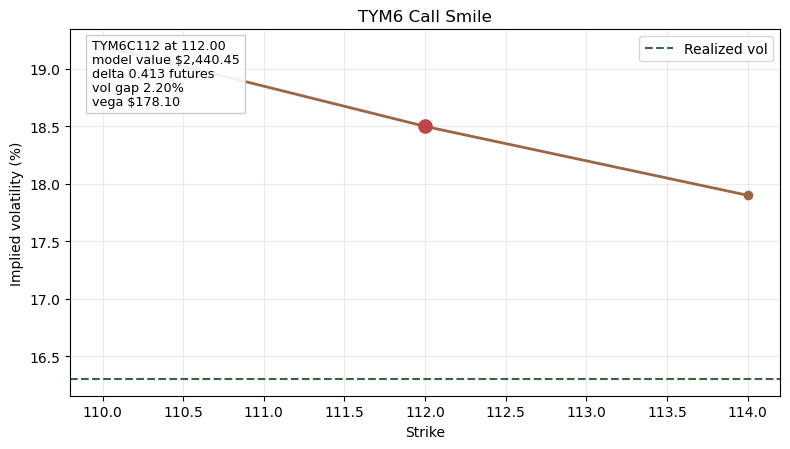

In [22]:
black76 = Black76Pricer()
option_smile_rows = []
selected_overlay = None

for row in option_smile:
    instrument_id = row['instrument_id']
    option_entry = option_reference_slice.loc[instrument_id]
    option = FuturesOption(
        instrument_id=instrument_id,
        expiry_date=Date.parse(option_entry['expiry_date']),
        underlying_future=hedge_future,
        strike=dec(option_entry['strike']),
        option_type=option_entry['option_type'],
    )
    implied_vol = dec(option_quote.loc[(instrument_id, 'lognormal_vol')])
    option_result = black76.futures_option(
        option,
        curves=AnalyticsCurves(discount_curve=discount_curve),
        futures_price=future_price,
        volatility=implied_vol,
        valuation_date=trade_date,
    )
    option_signal = option_rv_signal(
        implied_volatility=implied_vol,
        realized_volatility=option_realized_volatility,
        greeks=option_result.greeks,
    )
    delta_equivalent = option_result.greeks.delta / option.contract_multiplier()
    option_smile_rows.append({
        'strike': float(option.strike),
        'implied_vol': implied_vol,
    })
    if instrument_id == rates_option_id:
        selected_overlay = {
            'result': option_result,
            'signal': option_signal,
            'delta_equivalent': delta_equivalent,
            'strike': float(option.strike),
        }

overlay_note = '\n'.join([
    f"{rates_option_id} at {selected_overlay['strike']:.2f}",
    f"model value ${float(selected_overlay['result'].present_value):,.2f}",
    f"delta {float(selected_overlay['delta_equivalent']):.3f} futures",
    f"vol gap {pct(selected_overlay['signal'].volatility_gap)}",
    f"vega ${float(selected_overlay['signal'].vega_notional):,.2f}",
])

figure, axis = plt.subplots(figsize=(8.0, 4.6))
axis.plot(
    [row['strike'] for row in option_smile_rows],
    [100.0 * float(row['implied_vol']) for row in option_smile_rows],
    marker='o',
    linewidth=2.0,
    color='#9c6644',
)
axis.scatter([selected_overlay['strike']], [100.0 * float(selected_overlay['signal'].implied_volatility)], s=90, color='#bc4749', zorder=3)
axis.axhline(100.0 * float(selected_overlay['signal'].realized_volatility), linestyle='--', color='#386641', linewidth=1.5, label='Realized vol')
axis.set_title('TYM6 Call Smile')
axis.set_xlabel('Strike')
axis.set_ylabel('Implied volatility (%)')
axis.grid(alpha=0.25)
axis.text(0.03, 0.97, overlay_note, transform=axis.transAxes, va='top', ha='left', fontsize=9.2, bbox={'facecolor': 'white', 'edgecolor': '#c7c7c7', 'alpha': 0.9})
axis.legend()
plt.tight_layout()
plt.show()


## 8. Takeaway

- `ACME_CDS_5Y` still looks cleaner than financed cash for the long-credit view.
- Funding and EUR/USD basis both compress the bond once the spread is put on a common footing.
- `short TYM6` is the simple rate hedge, and `TYM6C112` stays a small convexity sleeve.
